In [ ]:
# SVM on wine dataset 

In [ ]:
# Steps
''' 
1. Import Libraries 
2. Load the dataset
3. Train test split
4. Preprocess the data (if needed) - Scaling, Encoding, etc.
5. Train the SVM model
6. Evaluate the model
7. Hyperparameter tuning (if needed) Grid SearchCV
8. Evaluate best model and interpret results
9. Visualize decision boundaries (if applicable)
'''

In [1]:
# import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, svm

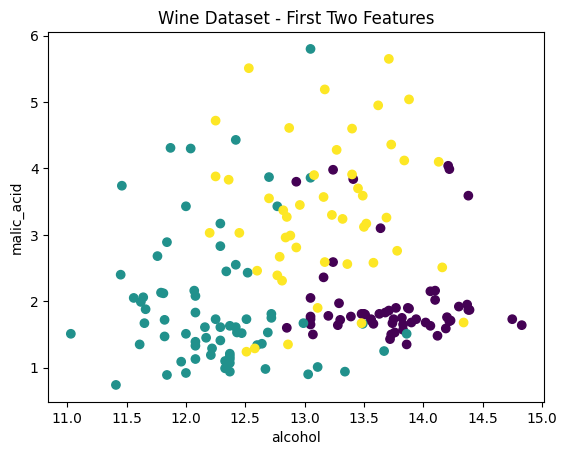

In [2]:
# load the wine dataset
wine = datasets.load_wine()
X = wine.data[:, :2]  # we only take the first two features for visualization
y = wine.target
# plot the data
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
plt.xlabel(wine.feature_names[0])   
plt.ylabel(wine.feature_names[1])
plt.title('Wine Dataset - First Two Features')
plt.show()


In [22]:
# describe the dataset
print("Feature names:", wine.feature_names)
print("Target names:", wine.target_names)
print("Data shape:", X.shape)


Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names: ['class_0' 'class_1' 'class_2']
Data shape: (178, 13)


In [13]:
# Take all features for training the SVM model
X = wine.data
y = wine.target

In [14]:
# split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Scale the features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [16]:
# Fit the SVM model
model = svm.SVC(kernel='linear', C=1)
model.fit(X_train_scaled, y_train)
# Evaluate the model
accuracy = model.score(X_test_scaled, y_test)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.97


In [17]:
# Hyperparameter tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf','poly','sigmoid'],
    'gamma': [0.01, 0.1, 1, 10, 100, 'scale', 'auto'],
    'degree': [2, 3, 4]  # Only relevant for 'poly' kernel
}   
grid = GridSearchCV(svm.SVC(), param_grid, refit=True, verbose=2,cv=5)
grid.fit(X_train_scaled, y_train)
print(f'Best Parameters: {grid.best_params_}')

Fitting 5 folds for each of 252 candidates, totalling 1260 fits
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.01, kernel=poly; total time=   0.0s
[CV] END ...........C=0.1, degree=2, gamma=0.

In [18]:
# fit the best model
best_model = grid.best_estimator_
best_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'sigmoid'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.01
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
# Accuracy of the best model
best_accuracy = best_model.score(X_test_scaled, y_test)
print(f'Best Model Accuracy: {best_accuracy:.2f}')

Best Model Accuracy: 1.00


In [ ]:
# Summary of results
# Data was visualized using the first two features of the wine dataset, showing clear separation between classes.
# Data was preprocessed by scaling all the features using StandardScaler.
# All features of the wine dataset were used for training the SVM model.
# Initial accuracy with default parameters was around 97.22%.
# Accuracy increased to 100% from 97.22% after hyperparameter tuning. 
# If we use only the first 2 features of the dataset, the accuracy was about 83%.
# The best parameters found were C=10, gamma=0.01, kernel='rbf', and degree=3 (though degree is not relevant for 'rbf' kernel). 
# This indicates that the SVM model with these parameters is able to perfectly classify the wine dataset in this case.

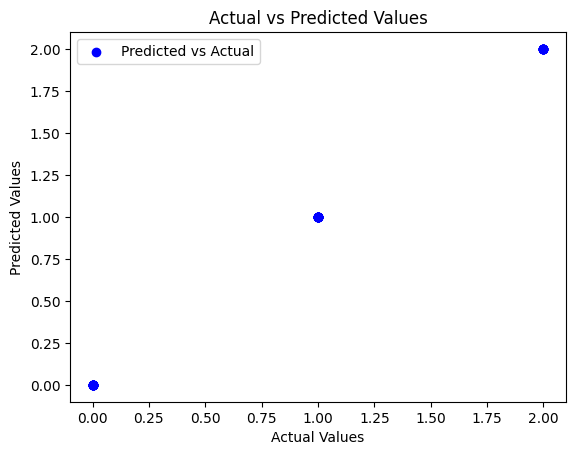

In [ ]:
# Assignment - Plot the scatter plot to plot Y actual and Y predicted values
y_pred = best_model.predict(X_test_scaled)
plt.scatter(y_test, y_pred, c='blue', marker='o', label='Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

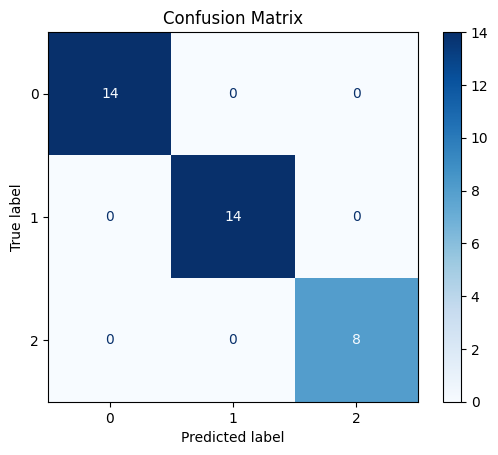

In [21]:
# Confusion metric
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

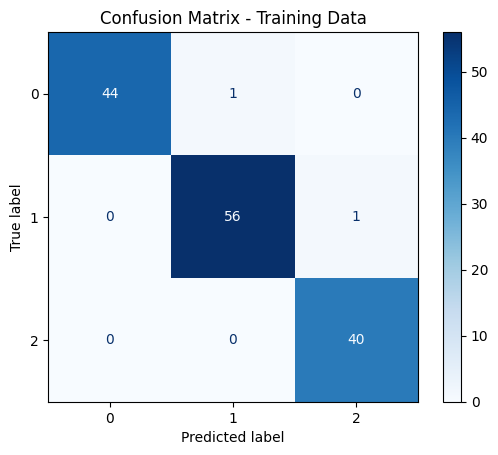

In [23]:
# Confusion metric on training data
y_train_pred = best_model.predict(X_train_scaled)
cm_train = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=best_model.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Training Data")
plt.show()